Install Library
Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "C:\\Users\\santo\\OneDrive\\Dokumen\\DiBimbing\\BIG PROJECT\\Data Cleaned\\supply_chain_cleaned.csv"
)

df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date,shipping_mode,delivery_days,profit_margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3,29.001397
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5,-80.000645
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,4,-80.001291
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,3,7.499754
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2,44.999164


Convert Date

In [2]:
df['order_date'] = pd.to_datetime(df['order_date'])

Monthly Revenue Dataset

In [4]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key='order_date',
            freq='ME'
        )
    )['sales_per_customer']
    .sum()
    .reset_index()
)

monthly_sales.columns = ['ds', 'y']

monthly_sales.head()

,ds,y
0,2015-01-31,945382.160534
1,2015-02-28,833012.429253
2,2015-03-31,944050.110472
3,2015-04-30,912004.400261
4,2015-05-31,943939.769956


Forecaseting Model

In [5]:
from prophet import Prophet

model = Prophet()

model.fit(monthly_sales)

Importing plotly failed. Interactive plots will not work.
15:53:52 - cmdstanpy - INFO - Chain [1] start processing
15:53:54 - cmdstanpy - INFO - Chain [1] done processing


Predict Future

In [7]:
future = model.make_future_dataframe(
    periods=6,
    freq='ME'
)

forecast = model.predict(future)


Visual Forecast

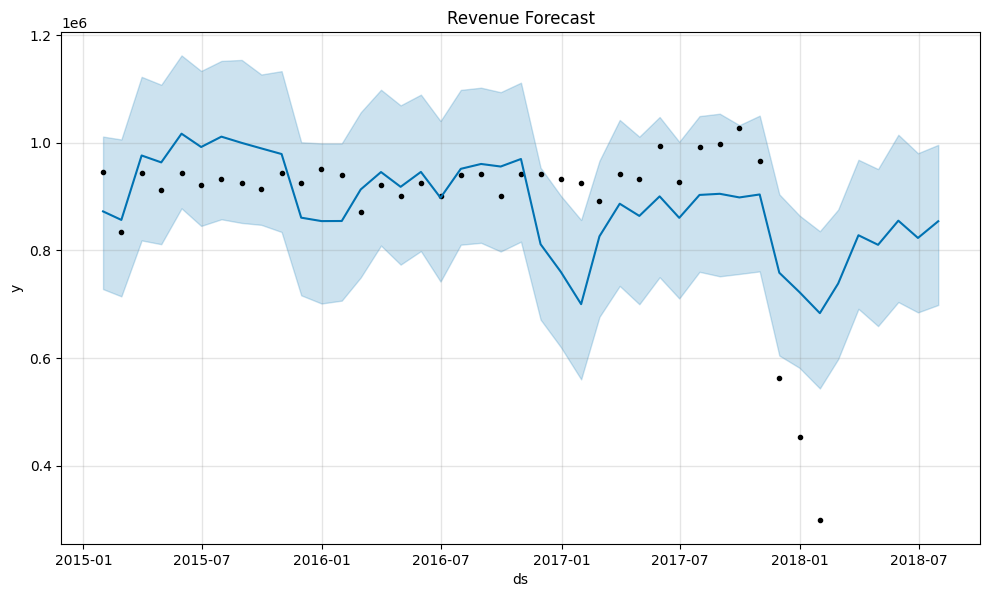

In [8]:
fig = model.plot(forecast)

plt.title("Revenue Forecast")
plt.show()

In [12]:
#save forecast to csv
forecast_output = forecast[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
]

forecast_output.to_csv(
   "C:\\Users\\santo\\OneDrive\\Dokumen\\DiBimbing\\BIG PROJECT\\Data Cleaned\\revenue_forecast.csv",
    index=False
)

print("Forecast Saved")

Forecast Saved
